# KMeans analysis

This notebook loads the 1 week lagged dataset and runs KMeans over a range of k. It computes elbow curve, silhouette score, and the Calinski-Harabasz index, and shows plots and cluster visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from collections import defaultdict
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../dataset_generators/datasets/final_1_lag_ffa_dataset.csv')

drop_cols = [c for c in df.columns if c.startswith('opp_team_')] + ['fantasy_points']

key_stats = [
    'passing_yards','passing_tds','passing_interceptions','rushing_yards','rushing_tds',
    'receiving_yards','receiving_tds','rushing_fumbles_lost','sack_fumbles_lost'
]

# QBs only
q = df[df['position'] == 'QB'].copy()

#  rush_share column
p = np.maximum(q['passing_yards_r_avg_8_lag_1'], 0.0)
r = np.maximum(q['rushing_yards_r_avg_8_lag_1'], 0.0)
alpha = 50.0
p_mean = p.mean(); r_mean = r.mean()
den = (p + r) + alpha*(p_mean + r_mean)
num = r + alpha*r_mean
q['rush_share_8'] = np.where(den > 0, num / den, np.nan)
q['rush_share_8'] = q['rush_share_8'].clip(0, 1)


rush_share_8 skewness: 1.661


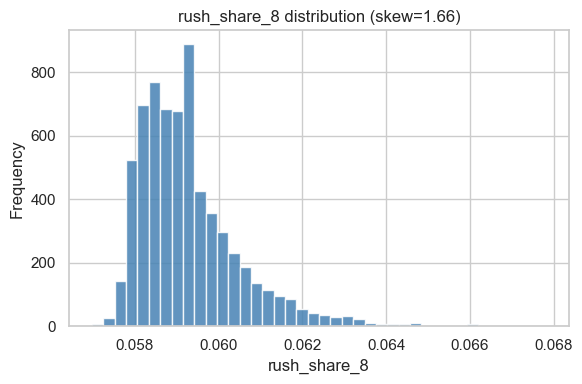

In [3]:
skew_val = q['rush_share_8'].skew()
print(f'rush_share_8 skewness: {skew_val:.3f}')
plt.figure(figsize=(6,4))
plt.hist(q['rush_share_8'].dropna(), bins=40, color='steelblue', alpha=0.85)
plt.title(f'rush_share_8 distribution (skew={skew_val:.2f})')
plt.xlabel('rush_share_8')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [4]:

# log transform
zdiv = 1e-4
rush_share = q['rush_share_8'].clip(zdiv, 1)
q['rush_share_8_log'] = np.log(rush_share)

# Select 8-game rolling average features
feature_cols = [f'{stat}_r_avg_8_lag_1' for stat in key_stats if f'{stat}_r_avg_8_lag_1' in q.columns]
feature_cols.append('rush_share_8_log')

# Remove any ordinal variables
ord_cols = [c for c in q.columns if 'rank' in c.lower()]
q = q.drop(columns=ord_cols, errors='ignore')

# Drop target & opponent context columns
q = q.drop(columns=[c for c in drop_cols if c in q.columns], errors='ignore')

# Keep only selected features
all_features = feature_cols
df_numeric = q[all_features].copy()

def remove_out_df(df, features):
    df_wins = df.copy()
    for season, group in df.groupby('season'):
        for col in features:
            if col in group.columns:
                lower = group[col].quantile(0.01)
                upper = group[col].quantile(0.99)
                idx = group.index
                df_wins.loc[idx, col] = group[col].clip(lower, upper)
    return df_wins

if 'season' in q.columns:
    df_numeric = remove_out_df(q.assign(**df_numeric), all_features)

df_numeric_scaled = []
for season, group in df_numeric.groupby('season'):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(group[all_features])
    df_numeric_scaled.append(pd.DataFrame(scaled, columns=all_features, index=group.index))
df_numeric = pd.concat(df_numeric_scaled).sort_index()

X_scaled = df_numeric.values

df_numeric.columns

Index(['passing_yards_r_avg_8_lag_1', 'passing_tds_r_avg_8_lag_1',
       'passing_interceptions_r_avg_8_lag_1', 'rushing_yards_r_avg_8_lag_1',
       'rushing_tds_r_avg_8_lag_1', 'receiving_yards_r_avg_8_lag_1',
       'receiving_tds_r_avg_8_lag_1', 'rushing_fumbles_lost_r_avg_8_lag_1',
       'sack_fumbles_lost_r_avg_8_lag_1', 'rush_share_8_log'],
      dtype='object')

In [5]:
def run_kmeans_metrics(X, k_range, random_state=42, sample=None):
    results = []
    models = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)

        if sample is not None:
            idx = np.random.RandomState(random_state).choice(X.shape[0], size=sample, replace=False)
            X_fit = X[idx]
        else:
            X_fit = X

        labels = km.fit_predict(X_fit)
        inertia = km.inertia_
        silhouette = silhouette_score(X_fit, labels)
        ch_score = calinski_harabasz_score(X_fit, labels)
        results.append({'k': k, 'inertia': inertia, 'silhouette': silhouette, 'calinski_harabasz': ch_score})
        models[k] = km
    return pd.DataFrame(results), models

k_range = list(range(2, 11))
res, models = run_kmeans_metrics(X_scaled, k_range)

res.head(5)



,k,inertia,silhouette,calinski_harabasz
0,2,51659.892805,0.256700,1386.897984
1,3,42640.475275,0.252921,1538.972567
2,4,37672.247185,0.265468,1451.601597
3,5,34404.879361,0.266141,1348.776179
4,6,31357.401731,0.243879,1312.110105


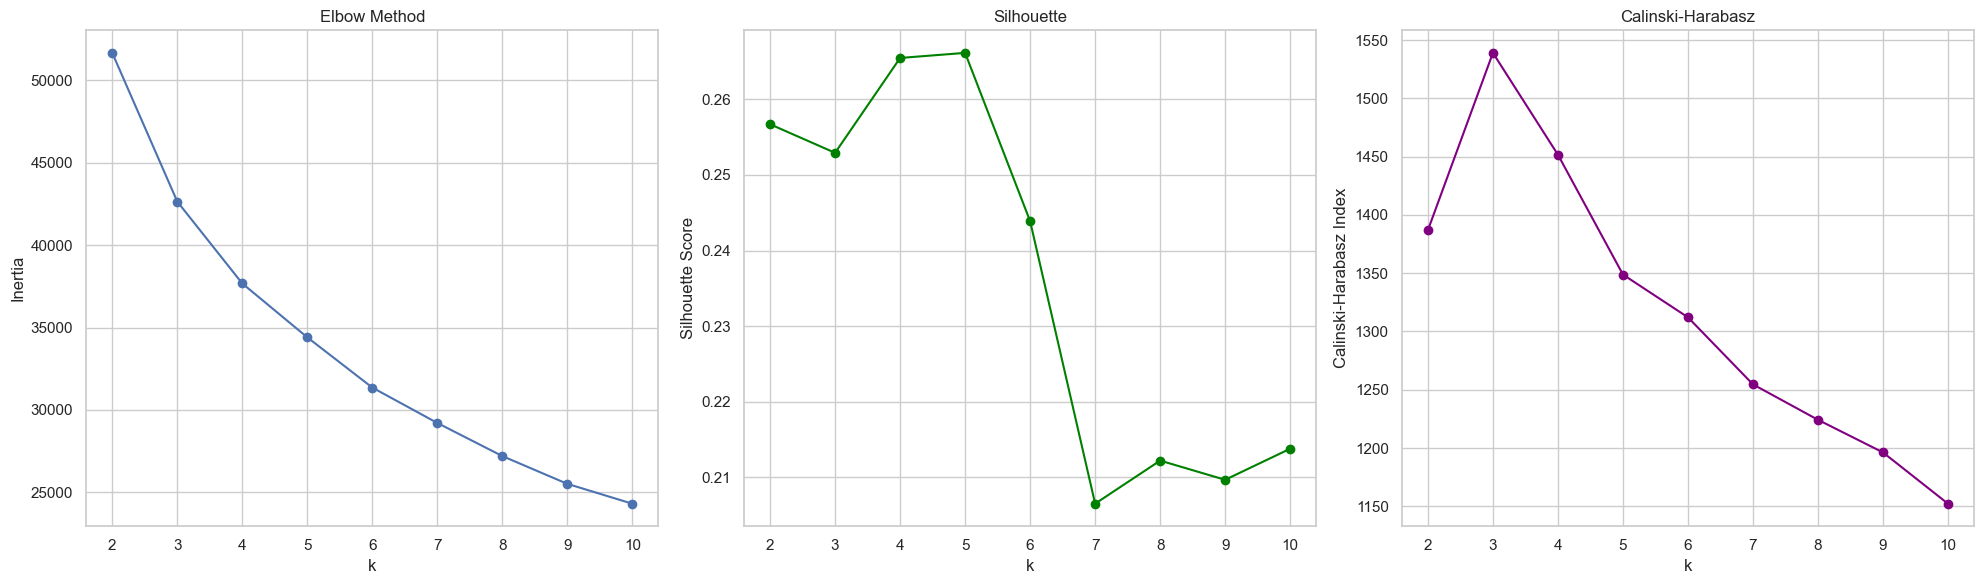

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(res['k'], res['inertia'], 'o-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(res['k'], res['silhouette'], 'o-', color='green')
axes[1].set_title('Silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[2].plot(res['k'], res['calinski_harabasz'], 'o-', color='purple')
axes[2].set_title('Calinski-Harabasz')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Index')

plt.tight_layout()
plt.show()


Generated seeds: [7270, 860, 5390, 5191, 5734]


inertia            silhouette           calinski_harabasz          
            mean        std       mean       std              mean       std
k                                                                           
2   51659.636490   0.091974   0.256160  0.000293       1386.934566  0.009635
3   42640.467799   0.010316   0.253183  0.000221       1538.974094  0.001222
4   37672.409480   0.256840   0.265885  0.000519       1451.586907  0.023314
5   34412.433414   9.682016   0.253462  0.017012       1348.121302  0.840214
6   31357.402163   0.007231   0.243881  0.000008       1312.110404  0.000346
7   29210.220347   0.137524   0.206336  0.000233       1254.542929  0.009923
8   27243.090975  91.964016   0.217687  0.012180       1220.933371  7.271282
9   25517.266679   0.107378   0.209580  0.000412       1196.203383  0.008746
10  24311.713839   0.671835   0.214411  0.000570       1152.223788  0.053342

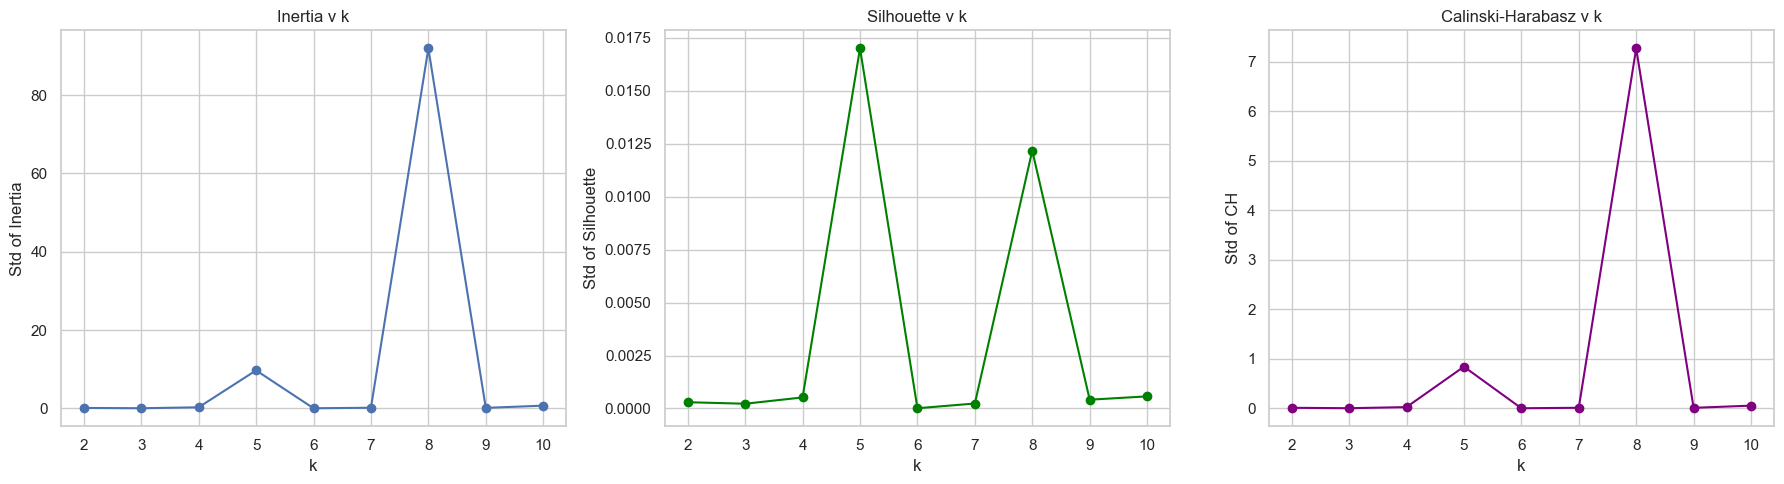

In [7]:
k_range = list(range(2, 11))
np.random.seed(42)
seeds = np.random.randint(0, 10000, size=5).tolist()
print(f"Generated seeds: {seeds}")
results = defaultdict(list)

for k in k_range:
    for seed in seeds:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertia = km.inertia_
        sil = silhouette_score(X_scaled, labels) if k > 1 else float('nan')
        ch = calinski_harabasz_score(X_scaled, labels) if k > 1 else float('nan')
        results['k'].append(k)
        results['seed'].append(seed)
        results['inertia'].append(inertia)
        results['silhouette'].append(sil)
        results['calinski_harabasz'].append(ch)

sens_df = pd.DataFrame(results)
sens_summary = sens_df.groupby('k').agg(['mean','std'])[['inertia','silhouette','calinski_harabasz']]

display(sens_summary)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_range, sens_summary['inertia']['std'], 'o-')
axes[0].set_title('Inertia v k')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Std of Inertia')
axes[1].plot(k_range, sens_summary['silhouette']['std'], 'o-', color='green')
axes[1].set_title('Silhouette v k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Std of Silhouette')
axes[2].plot(k_range, sens_summary['calinski_harabasz']['std'], 'o-', color='purple')
axes[2].set_title('Calinski-Harabasz v k')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Std of CH')
plt.tight_layout()
plt.show()


Cluster sizes:
0    3943
1    1191
2    1478
dtype: int64

Cluster centroids (key features):
   passing_yards_r_avg_8_lag_1  rushing_yards_r_avg_8_lag_1  rush_share_8_log
0                     0.473363                    -0.348752         -0.536440
1                    -1.731797                    -0.654145          0.049230
2                     0.134171                     1.457728          1.391044


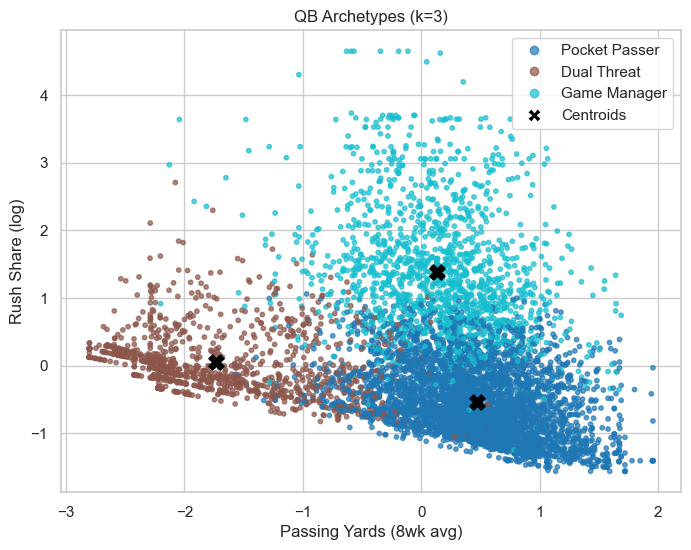


Pocket Passer example QBs:
  player_display_name  season  week  passing_yards_r_avg_8_lag_1  \
4     Matt Hasselbeck    2015     5                       282.00   
5     Matt Hasselbeck    2015    11                       247.50   
6     Matt Hasselbeck    2015    12                       236.00   
7     Matt Hasselbeck    2015    13                       255.75   
8     Matt Hasselbeck    2015    14                       238.40   

   rushing_yards_r_avg_8_lag_1  rush_share_8  
4                         1.00      0.057896  
5                        -1.00      0.057989  
6                         2.00      0.058213  
7                         0.75      0.058009  
8                         0.80      0.058101  

Dual Threat example QBs:
   player_display_name  season  week  passing_yards_r_avg_8_lag_1  \
0      Matt Hasselbeck    2014     4                        20.00   
1      Matt Hasselbeck    2014    16                        10.00   
2      Matt Hasselbeck    2014    17            

In [8]:
k = 3

km = models[k]
labels = km.predict(X_scaled)
centroids = km.cluster_centers_

# Show cluster sizes
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print(f"Cluster sizes:\n{cluster_sizes}")

# Show cluster centroids
key_features = ['passing_yards_r_avg_8_lag_1', 'rushing_yards_r_avg_8_lag_1', 'rush_share_8_log']
centroid_df = pd.DataFrame(centroids, columns=df_numeric.columns)
print("\nCluster centroids (key features):")
print(centroid_df[key_features])

# Visualize clusters
plt.figure(figsize=(8,6))
scatter = plt.scatter(df_numeric['passing_yards_r_avg_8_lag_1'], df_numeric['rush_share_8_log'], c=labels, cmap='tab10', s=10, alpha=0.7)
plt.scatter(centroid_df['passing_yards_r_avg_8_lag_1'], centroid_df['rush_share_8_log'], c='black', marker='X', s=120, label='Centroids')
plt.xlabel('Passing Yards (8wk avg)')
plt.ylabel('Rush Share (log)')
plt.title(f'QB Archetypes (k={k})')

# Assign descriptive names to archetypes
archetypes = ['Pocket Passer', 'Dual Threat', 'Game Manager']
handles, _ = scatter.legend_elements()
plt.legend(handles + [plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='Centroids')], archetypes + ['Centroids'], loc='best')
plt.show()

# Show example players from each
q['cluster'] = labels
for c in range(k):
    print(f"\n{archetypes[c]} example QBs:")
    print(q[q['cluster'] == c][['player_display_name','season','week','passing_yards_r_avg_8_lag_1','rushing_yards_r_avg_8_lag_1','rush_share_8']].head(5))